In [18]:
#dependencias
import os
import sys
from pathlib import Path
import geopandas as gpd
import pandas as pd
import h3
from shapely.geometry import Polygon
import numpy as np
import matplotlib.pyplot as plt

%store -r ruta

In [19]:
# Cargamos el archivo que creamos en el otro notebook
red_vial = gpd.read_file(Path(ruta) / 'data' / 'data_generada' / 'red_vial_procesada.gpkg')

# Verificamos que traiga el CRS correcto (debería ser EPSG:32719 o similar)
print(f"CRS recuperado: {red_vial.crs}")

CRS recuperado: EPSG:32719


In [7]:
# Función corregida para H3 v4
def hex_to_poly(h3_index):
    try:
        # cell_to_boundary devuelve ((lat, lon), (lat, lon)...)
        boundary_latlon = h3.cell_to_boundary(h3_index)
        # Invertimos a (lon, lat) para GeoPandas
        boundary_lonlat = [(lon, lat) for lat, lon in boundary_latlon]
        return Polygon(boundary_lonlat)
    except:
        return None

# Estimar Densidad de Atasco (Kj)
# Referencia: ~130-150 veh/km por carril.
def get_lanes(val):
    try:
        n = int(val)
        # CORRECCIÓN: Si n es 0 o negativo, forzamos que sea al menos 1
        return max(1, n)
    except:
        return 1 # Si falla o es nulo, asumimos 1 carril por defecto

# B. Resolver ecuación cuadrática de Greenshields para obtener k
# q = k * vf * (1 - k/kj)  ==>  (vf/kj)*k^2 - vf*k + q = 0
def solve_greenshields(row):
    vf = row['velocidad_vf']
    kj = row['kj']
    q = row['flujo_q']
    
    # PROTECCIÓN ADICIONAL:
    # Si por alguna razón kj llegara a ser 0 o muy pequeño, retornamos 0 para evitar error
    if kj <= 1e-5: 
        return 0
        
    # Coeficientes ax^2 + bx + c = 0 para la ecuación: q = k * vf * (1 - k/kj)
    # Equivalente a: (vf/kj)*k^2 - vf*k + q = 0
    a = vf / kj
    b = -vf
    c = q
    
    delta = b**2 - 4*a*c
    
    if delta < 0:
        # Flujo excede capacidad teórica -> Saturación total
        # Retornamos densidad crítica (Kj/2)
        return kj / 2
    else:
        # Dos soluciones. Usamos la menor (rama no congestionada)
        # k = (-b - sqrt(delta)) / 2a
        k_sol = (-b - np.sqrt(delta)) / (2*a)
        return k_sol

#PREPARACIÓN DE DATOS DE MOVILIDAD
print("1. Procesando datos de movilidad...")
try:
    df_movilidad = pd.read_csv(Path(ruta) / 'data' / 'miercoles_rm.csv')
    
    # Filtro: Hora punta tarde (18:00)
    hora_analisis = 18 
    df_hora = df_movilidad[df_movilidad['hora'] == hora_analisis].copy()

    df_hora['geometry'] = df_hora['h3_9'].apply(hex_to_poly)
    df_hora = df_hora.dropna(subset=['geometry'])
    
    # Crear GeoDataFrame de zonas
    gdf_zonas = gpd.GeoDataFrame(df_hora, geometry='geometry', crs="EPSG:4326")
    
    # Homogeneizar proyecciones (Crítico: ambas en Metros/UTM)
    if red_vial.crs != gdf_zonas.crs:
        gdf_zonas = gdf_zonas.to_crs(red_vial.crs)

except Exception as e:
    print(f"Error procesando CSV: {e}")

# CRUCE ESPACIAL (SPATIAL JOIN)
print("Cruzando Red Vial con Zonas H3 (esto puede tomar unos segundos)")
# Asignamos a cada calle los datos del hexágono que la toca
# 'inner' solo mantiene calles con datos, 'left' mantiene todas (rellenaremos después)
red_vial_con_datos = gpd.sjoin(red_vial, gdf_zonas[['poblacion_flotante', 'geometry']], how='left', predicate='intersects')

# ESTIMACIÓN DE FLUJO (Q)
print("Estimando Flujo Vehicular (q)")


#REVISAR ESTE SUPUESTO
# A. Imputación: Si no hay datos de Uber, asumimos flujo mínimo basal
# (Ej: 20 personas flotantes ~ 2 veh/h en pasajes vacíos)
red_vial_con_datos['poblacion_flotante'] = red_vial_con_datos['poblacion_flotante'].fillna(20)

# B. Factor de Conversión (Calibración)
# Supuesto: 10% de la población se traduce en vehículos/hora en esa vía
FACTOR_CONVERSION = 0.1 
red_vial_con_datos['flujo_q'] = red_vial_con_datos['poblacion_flotante'] * FACTOR_CONVERSION

# C. Limpieza: Si una calle cruza varios hexágonos, promediamos el flujo
# Mantenemos las columnas geométricas y de tráfico originales
cols_to_keep = ['geometry', 'velocidad_vf', 'name', 'highway', 'lanes', 'maxspeed', 'other_tags']
# Aseguramos que existan en el df antes de agrupar
cols_existentes = [c for c in cols_to_keep if c in red_vial_con_datos.columns]

red_vial_final = red_vial_con_datos.dissolve(by='osm_id', aggfunc={
    'flujo_q': 'mean',
    **{c: 'first' for c in cols_existentes if c != 'geometry'} 
}).reset_index()

# cÁLCULO DE DENSIDAD (K) - MODELO GREENSHIELDS
print("4. Calculando Densidad (k) y Velocidad Operativa (v)...")

red_vial_final['num_carriles'] = red_vial_final['lanes'].apply(get_lanes)
red_vial_final['kj'] = red_vial_final['num_carriles'] * 140 # [cite: 190]
red_vial_final['densidad_k'] = red_vial_final.apply(solve_greenshields, axis=1)

# C. Calcular Velocidad Operativa Real (v)
# v = q / k
# Evitamos división por cero
red_vial_final['velocidad_op'] = red_vial_final['flujo_q'] / red_vial_final['densidad_k'].replace(0, 0.001)

print("✅ ¡Proceso finalizado! 'red_vial_final' tiene los inputs para el modelo acústico.")
print(red_vial_final[['name', 'flujo_q', 'densidad_k', 'velocidad_op']].head())

1. Procesando datos de movilidad...
Cruzando Red Vial con Zonas H3 (esto puede tomar unos segundos)
Estimando Flujo Vehicular (q)
4. Calculando Densidad (k) y Velocidad Operativa (v)...
✅ ¡Proceso finalizado! 'red_vial_final' tiene los inputs para el modelo acústico.
                 name    flujo_q  densidad_k  velocidad_op
0            Gran Via  27.589375    0.922686     29.901141
1            Gran Via  51.558500    1.740249     29.627090
2           La Rambla  18.946750    0.379449     49.932241
3  Juan Emilio Pacull  20.258500    0.405758     49.927543
4        Anibal Pinto  35.471079    1.187405     29.872778


5. Calculando Niveles de Ruido (Leq) por tramo...

--- Top 5 Tramos con Mayor Emisión de Ruido [dB(A)] ---


,name,velocidad_op,densidad_k,ruido_leq
30545,Autopista Costanera Norte,74.997432,26.263483,93.189213
20669,Autopista Vespucio Sur,97.961446,8.561927,92.519007
20668,Autopista Vespucio Sur,97.961446,8.561927,92.519007
2633,Autopista Central,98.298542,7.146124,91.788076
16996,Autopista Costanera Norte,77.140483,15.012466,91.202241


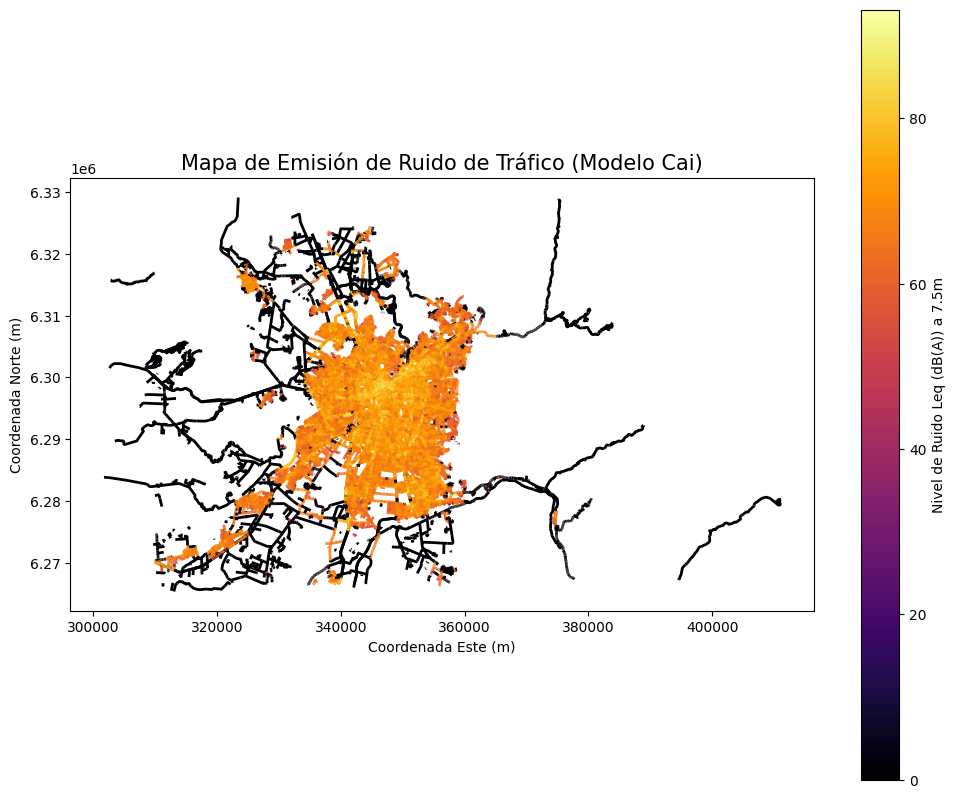

In [9]:
# --- PARÁMETROS DEL MODELO (Sección 5.2) ---
# Composición vehicular asumida (Sección 6.9.1 sugiere supuestos si no hay datos)
# Aquí usamos un mix estándar urbano: 95% Autos, 5% Camiones/Buses
PORC_LIGEROS = 0.95
PORC_PESADOS = 0.05

# Distancia de referencia r0 (Ec. 15)
R0 = 7.5  # metros

def modelo_emision_cai(row):
    """
    Calcula el Leq a 7.5m del eje de la vía basándose en velocidad y densidad.
    Implementa Ecuaciones 14 y 36 del documento.
    """
    v = row['velocidad_op'] # Velocidad operativa calculada
    k = row['densidad_k']   # Densidad calculada
    
    # Validación física: Si v < 1 km/h o k < 0.1 veh/km, el ruido es despreciable (o basal)
    if v < 1 or k < 0.1:
        return 0
    
    # 1. CÁLCULO DE L0 (Nivel base por vehículo individual) - Ec. 14
    # Ligeros
    l0_light = 33.66 * np.log10(v) + 12.60
    # Pesados
    l0_heavy = 38.10 * np.log10(v) + 18.00
    
    # 2. CÁLCULO DE Leq POR CATEGORÍA - Ec. 36 simplificada
    # Leq_i = L0_i + 10*log10(k_i)
    # k_i es la densidad parcial de esa categoría
    
    k_light = k * PORC_LIGEROS
    k_heavy = k * PORC_PESADOS
    
    # Evitar log(0)
    leq_light = l0_light + 10 * np.log10(k_light) if k_light > 0 else 0
    leq_heavy = l0_heavy + 10 * np.log10(k_heavy) if k_heavy > 0 else 0
    
    # 3. SUMA ENERGÉTICA TOTAL (Ec. 16)
    # Leq_total = 10 * log10( 10^(Leq_L/10) + 10^(Leq_P/10) )
    suma_energia = (10**(leq_light/10)) + (10**(leq_heavy/10))
    leq_total = 10 * np.log10(suma_energia)
    
    return leq_total

print("5. Calculando Niveles de Ruido (Leq) por tramo...")
red_vial_final['ruido_leq'] = red_vial_final.apply(modelo_emision_cai, axis=1)

# --- RESULTADOS Y VISUALIZACIÓN ---

# Mostramos los tramos más ruidosos
print("\n--- Top 5 Tramos con Mayor Emisión de Ruido [dB(A)] ---")
display(red_vial_final[['name', 'velocidad_op', 'densidad_k', 'ruido_leq']].sort_values(by='ruido_leq', ascending=False).head())

# Mapa de Calor Acústico
fig, ax = plt.subplots(figsize=(12, 10))
red_vial_final.plot(column='ruido_leq', 
                    ax=ax, 
                    legend=True,
                    cmap='inferno',  # 'inferno' es excelente para mapas de calor/intensidad
                    legend_kwds={'label': "Nivel de Ruido Leq (dB(A)) a 7.5m"},
                    linewidth=2)

ax.set_title("Mapa de Emisión de Ruido de Tráfico (Modelo Cai)", fontsize=15)
ax.set_xlabel("Coordenada Este (m)")
ax.set_ylabel("Coordenada Norte (m)")
plt.show()

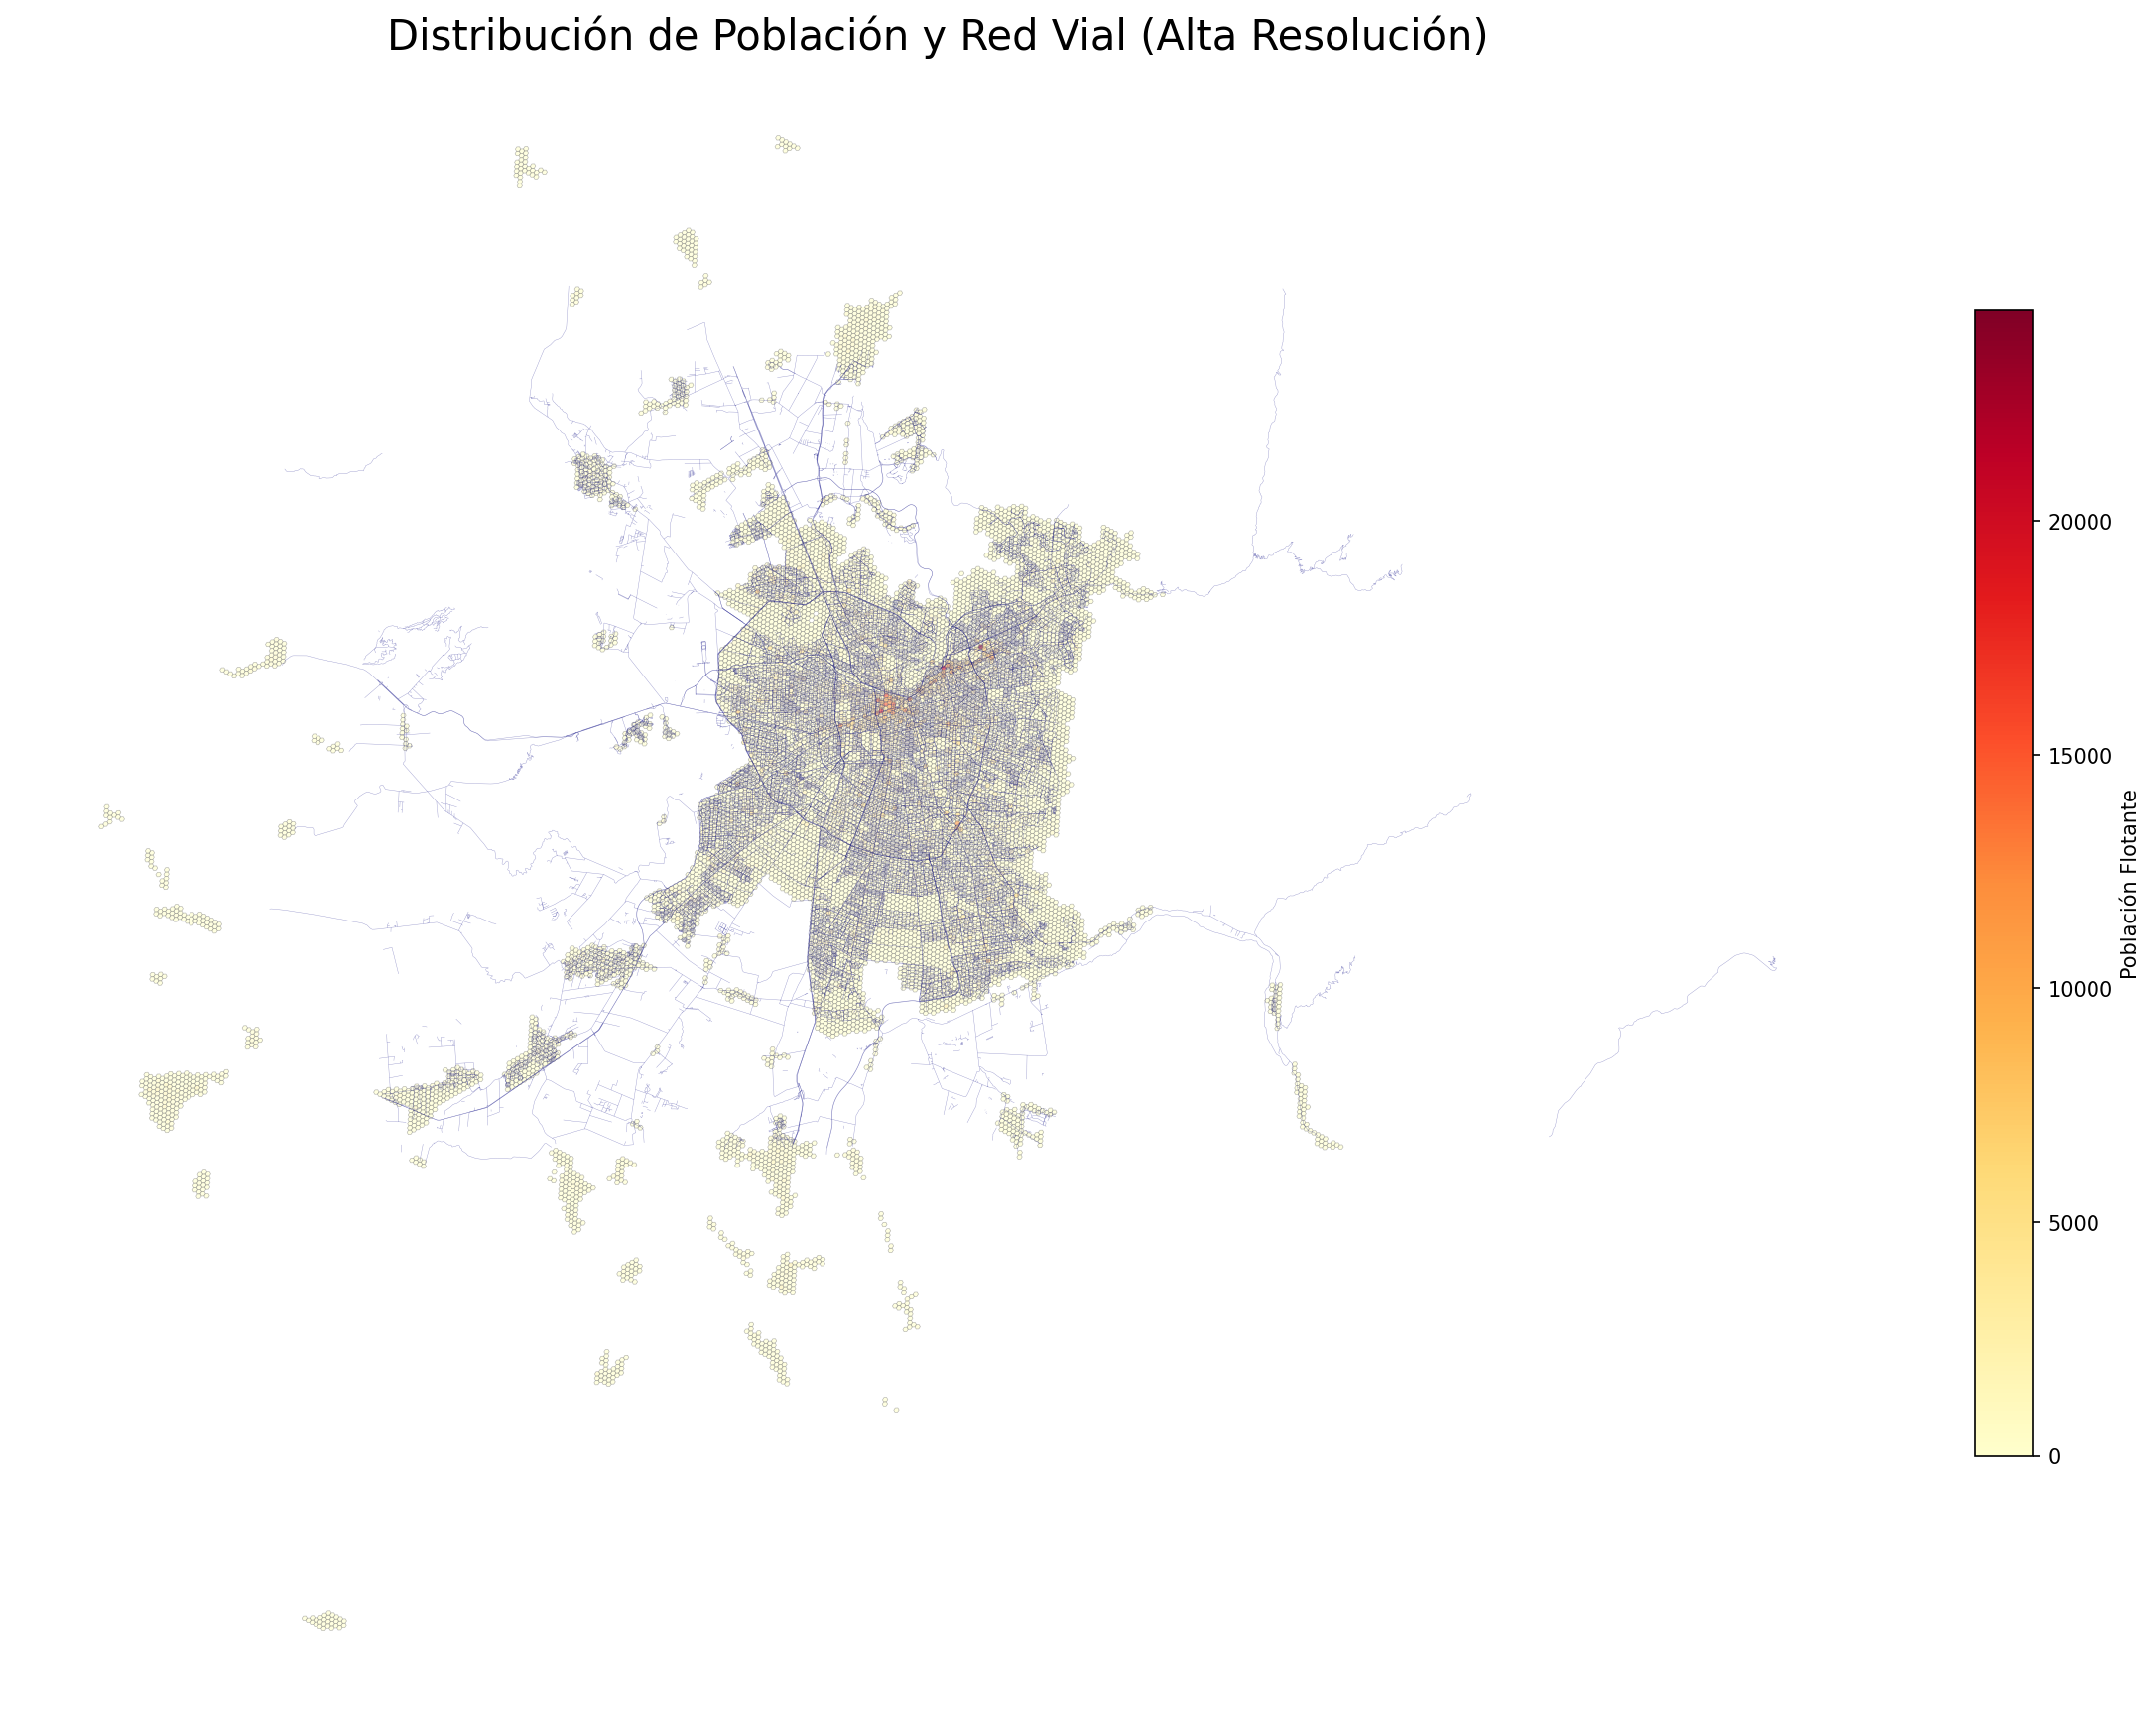

In [13]:
# 1. Preparar datos de movilidad (Receptores)
df_movilidad = pd.read_csv(Path(ruta) / 'data' / 'miercoles_rm.csv')

# Filtramos una hora específica (ej. 18:00 PM)
hora_target = 18
df_hex = df_movilidad[df_movilidad['hora'] == hora_target].copy()

# 2. Generar geometría de Hexágonos (H3 v4)
def crear_hexagono(h3_index):
    try:
        # Obtener vértices ((lat, lon), ...)
        boundary = h3.cell_to_boundary(h3_index)
        # Invertir a (lon, lat) para GeoPandas
        poly_points = [(lon, lat) for lat, lon in boundary]
        return Polygon(poly_points)
    except:
        return None

df_hex['geometry'] = df_hex['h3_9'].apply(crear_hexagono)
gdf_hex = gpd.GeoDataFrame(df_hex, geometry='geometry', crs="EPSG:4326")

# Reproyectar a metros para coincidir con la red vial (UTM 19S)
# Asumiendo que ya definiste red_vial en pasos anteriores
if 'red_vial' in locals():
    gdf_hex = gdf_hex.to_crs(red_vial.crs)

# 3. Visualización: Mapa de Densidad de Población Flotante
fig, ax = plt.subplots(figsize=(20, 20), dpi=150)

# 1. Graficar Hexágonos
gdf_hex.plot(
    column='poblacion_flotante',
    ax=ax,
    legend=True,
    cmap='YlOrRd',
    alpha=0.6,
    edgecolor='grey',     # Bordes grises sutiles
    linewidth=0.3,
    legend_kwds={'label': "Población Flotante", 'shrink': 0.5}
)

# 2. Graficar Calles (más finas para no tapar)
if 'red_vial' in locals():
    red_vial.plot(
        ax=ax, 
        color='navy', 
        linewidth=0.2, 
        alpha=0.4
    )

# 3. Zoom Específico (Opcional)
# Si quieres ver solo el centro, descomenta y ajusta estas coordenadas (UTM)
# ax.set_xlim(345000, 350000) 
# ax.set_ylim(6295000, 6300000)

ax.set_title("Distribución de Población y Red Vial (Alta Resolución)", fontsize=20)
ax.axis('off') # Quitar ejes para que se vea limpio

plt.show()

In [14]:
# Crear mapa interactivo de los hexágonos de población
# Usamos 'alpha' para que sea semitransparente y se vean las calles abajo
m_hex = gdf_hex.explore(
    column='poblacion_flotante',  # Colorear por cantidad de gente
    cmap='YlOrRd',                # Mapa de color (Amarillo a Rojo)
    style_kwds={
        'stroke': True,           # Dibujar bordes del hexágono
        'color': 'black',         # Color del borde
        'weight': 0.5,            # Grosor del borde (fino)
        'fillOpacity': 0.6        # Transparencia del relleno
    },
    legend=True,
    tooltip=['h3_9', 'poblacion_flotante'], # Datos al pasar el mouse
    name="Población Flotante (H3)"
)

# Si quieres agregar la red vial encima para ver la coincidencia:
if 'red_vial' in locals():
    # Agregamos la red vial al mismo mapa 'm_hex'
    m_hex = red_vial.explore(
        m=m_hex,                  # Añadir al mapa anterior
        color='blue',
        style_kwds={'weight': 1}, # Líneas finas
        name="Red Vial",
        tooltip=['name']
    )

m_hex.save(Path(ruta) / 'data' / 'data_generada' / 'm_hex.html')

In [15]:
print("1. Preparando intersección geométrica (Corte de calles por hexágonos)...")

# Aseguramos que ambos GDF tengan solo las columnas necesarias para no ensuciar
# red_vial_final: Geometría de calles y su nivel de ruido Leq
cols_vial = ['ruido_leq', 'geometry']
# gdf_zonas: Geometría de hexágonos y su ID
cols_zona = ['h3_9', 'poblacion_flotante', 'geometry']

# INTERSECCIÓN (OVERLAY):
# Esto corta las líneas de calle por los polígonos de hexágonos.
# El resultado son segmentos de calle, cada uno perteneciente a un único hexágono.
vias_en_hex = gpd.overlay(
    red_vial_final[cols_vial], 
    gdf_zonas[cols_zona], 
    how='intersection'
)

# Calculamos la longitud de cada segmento cortado (para ponderar)
vias_en_hex['longitud_segmento'] = vias_en_hex.length

print(f"   Generados {len(vias_en_hex)} segmentos de vía dentro de los hexágonos.")

# --- 2. CÁLCULO DE MÉTRICAS POR HEXÁGONO ---
print("2. Calculando ruido promedio energético por zona...")

def promedio_energetico(df_grupo):
    """
    Calcula el Leq promedio ponderado por longitud del tramo.
    Formula: 10 * log10( Sum(Li * 10^(Leq/10)) / Sum(Li) )
    """
    if df_grupo.empty or df_grupo['longitud_segmento'].sum() == 0:
        return 0
    
    # Conversión a Energía Acústica (lineal)
    energia = 10 ** (df_grupo['ruido_leq'] / 10)
    
    # Promedio ponderado por longitud del segmento
    longitud_total = df_grupo['longitud_segmento'].sum()
    energia_ponderada = (energia * df_grupo['longitud_segmento']).sum() / longitud_total
    
    # Volver a decibeles
    return 10 * np.log10(energia_ponderada)

# Agrupamos por ID de hexágono (h3_9)
stats_hex = vias_en_hex.groupby('h3_9').apply(
    lambda x: pd.Series({
        'ruido_ambiental_leq': promedio_energetico(x),
        'ruido_max': x['ruido_leq'].max(),
        'longitud_vias_km': x['longitud_segmento'].sum() / 1000
    })
)

# --- 3. UNIÓN FINAL CON GEOMETRÍA DE HEXÁGONOS ---
# Unimos las estadísticas calculadas de vuelta a los polígonos originales (gdf_zonas)
hex_resultados = gdf_zonas.merge(stats_hex, on='h3_9', how='left')

# Llenamos con 0 o ruido de fondo (ej. 40 dB) los hexágonos sin calles ruidosas
hex_resultados['ruido_ambiental_leq'] = hex_resultados['ruido_ambiental_leq'].fillna(40)
hex_resultados['ruido_max'] = hex_resultados['ruido_max'].fillna(40)

# --- 4. CÁLCULO DE EXPOSICIÓN (Enfoque Basso) ---
# Definimos "Población Expuesta" como aquella en zonas con Ruido > 65 dB(A) (Umbral crítico OCDE)
umbral_molestia = 65
hex_resultados['poblacion_expuesta_critica'] = np.where(
    hex_resultados['ruido_ambiental_leq'] > umbral_molestia,
    hex_resultados['poblacion_flotante'],
    0
)

# Índice de Riesgo Acústico (Simple): Ruido * Log(Poblacion)
# (Usamos log de población para que no se dispare la escala)
hex_resultados['indice_riesgo'] = hex_resultados['ruido_ambiental_leq'] * np.log1p(hex_resultados['poblacion_flotante'])

print("✅ Análisis por hexágonos completado.")
display(hex_resultados[['h3_9', 'poblacion_flotante', 'ruido_ambiental_leq', 'poblacion_expuesta_critica']].sort_values(by='ruido_ambiental_leq', ascending=False).head())

# --- 5. VISUALIZACIÓN ---
# Mapa Interactivo de Ruido Ambiental por Barrio
m_ruido = hex_resultados.explore(
    column='ruido_ambiental_leq',
    cmap='inferno',
    style_kwds={'fillOpacity': 0.7, 'weight': 0.1},
    legend=True,
    name="Ruido Ambiental Leq (dB)",
    tooltip=['h3_9', 'ruido_ambiental_leq', 'poblacion_flotante', 'poblacion_expuesta_critica']
)
m_ruido.save(Path(ruta) / 'data' / 'data_generada' / 'm_ruido.html')

1. Preparando intersección geométrica (Corte de calles por hexágonos)...
   Generados 76449 segmentos de vía dentro de los hexágonos.
2. Calculando ruido promedio energético por zona...
✅ Análisis por hexágonos completado.


C:\Users\Nicolas\AppData\Local\Temp\ipykernel_34888\2445863654.py:45: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats_hex = vias_en_hex.groupby('h3_9').apply(


,h3_9,poblacion_flotante,ruido_ambiental_leq,poblacion_expuesta_critica
4960,89b2c556817ffff,19696.937500,88.648183,19696.937500
9913,89b2c50938bffff,8387.387947,87.617443,8387.387947
4738,89b2c554163ffff,10851.002500,86.539148,10851.002500
876,89b2c55416fffff,3198.069835,85.802001,3198.069835
872,89b2c554133ffff,11640.312500,85.625805,11640.312500


In [16]:
# --- MAPA DE RIESGO ACÚSTICO (Exposición Ponderada) ---

# Usaremos un mapa de colores 'Reds' o 'OrRd' para denotar urgencia/peligro.
# Zonas blancas/claras = Bajo riesgo (Poco ruido O Poca gente).
# Zonas rojas oscuras = Alto riesgo (Mucho ruido Y Mucha gente).

m_riesgo = hex_resultados.explore(
    column='indice_riesgo',       # La métrica combinada que calculamos
    cmap='Reds',                  # Paleta de Rojos (Semáforo de alerta)
    style_kwds={
        'fillOpacity': 0.8,       # Bastante opaco para ver bien la "mancha" de riesgo
        'weight': 0.2,            # Bordes muy finos
        'color': 'black'
    },
    legend=True,
    legend_kwds={'caption': 'Índice de Riesgo (Ruido x Población)'},
    name="Mapa de Riesgo Acústico",
    tooltip=[
        'h3_9', 
        'ruido_ambiental_leq',       # Para ver la componente "Amenaza"
        'poblacion_flotante',        # Para ver la componente "Vulnerabilidad"
        'indice_riesgo',             # El resultado final
        'poblacion_expuesta_critica' # Personas sobre 65 dB
    ]
)

# Opcional: Agregar la red vial principal encima para referencia (solo avenidas)
if 'red_vial_final' in locals():
    # Filtramos solo las calles muy ruidosas (>70 dB) para no saturar el mapa
    vias_criticas = red_vial_final[red_vial_final['ruido_leq'] > 70]
    
    m_riesgo = vias_criticas.explore(
        m=m_riesgo,
        column='ruido_leq',
        cmap='inferno',
        style_kwds={'weight': 2},
        name="Vías Críticas (>70 dB)",
        tooltip=['name', 'ruido_leq']
    )

m_riesgo.save(Path(ruta) / 'data' / 'data_generada' / 'm_riesgo.html')